# 046 检测分割与结构化预测

从干净内核顺序运行。数据为原创合成，离线CPU。这个Notebook真正执行21次固定训练、比较保存结果、生成13张图。纸笔问题与完整答案分别见lab和answers。发布版使用新Python进程的真实InProcessKernel；未测试socket传输及浏览器Jupyter界面。

In [1]:
from pathlib import Path
import os, json, tempfile, numpy as np, torch
from IPython.display import display, Image
from reference import *
from experiment import run, load_data
ROOT = Path.cwd()
if not (ROOT / 'data' / 'metadata.json').is_file():
    raise RuntimeError('请从046目录启动内核')
workspace = Path(tempfile.mkdtemp(prefix='dl046-notebook-'))
print('NumPy', np.__version__, 'PyTorch', torch.__version__)
print('结果写入本次独立临时目录；原始发布结果不覆盖。')

NumPy 2.3.5 PyTorch 2.7.1+cpu
结果写入本次独立临时目录；原始发布结果不覆盖。


## 1 半开框、去重与AP
先预测数值：两个2×2框水平错开1，IoU多少？相同定位重复预测为何降低AP？以下单类评估没有crowd/ignore等，不能称完整COCO。

In [2]:
print('IoU:', iou([[0,0,2,2]], [[1,0,3,2]])[0,0])
print('编码:', encode_boxes([[0,0,2,2]], [[1,0,5,2]]))
print('NMS:', nms([[0,0,2,2],[0,0,2,2],[2,0,4,2]], [.9,.9,.8]))
gt=[{'image_id':'a','box':[0,0,2,2]},{'image_id':'b','box':[0,0,2,2]}]
pred=[dict(gt[0],score=.9),dict(gt[0],score=.8),dict(gt[1],score=.7)]
print(json.dumps(detection_ap(gt,pred),indent=2))

IoU: 0.3333333333333333
编码: [[1.         0.         0.69314718 0.        ]]
NMS: [0, 2]
{
  "order": [
    0,
    1,
    2
  ],
  "tp": [
    1,
    0,
    1
  ],
  "fp": [
    0,
    1,
    0
  ],
  "matched_gt": [
    0,
    null,
    1
  ],
  "precision": [
    1.0,
    0.5,
    0.6666666666666666
  ],
  "recall": [
    0.5,
    0.5,
    1.0
  ],
  "ap_all_point": 0.8333333333333333,
  "ap_101_point": 0.8349834983498351,
  "num_gt": 2
}


## 2 四像素共享梯度
所有像素共享w和b。下方记录包括每条局部导数和贡献；先手算第一轮，再检查两次同步更新及下一次前向。

In [3]:
ledger=hand_ledger()
for round_ in ledger:
    print('step', round_['step'], 'theta', round_['theta'], 'loss', round_['loss'], 'gradient', round_['gradient'])
for i,sample in enumerate(ledger[0]['samples']):
    print('sample',i)
    for pixel in sample['pixels']: print(pixel)

step 0 theta [0.6931471805599453, 0.0] loss 0.7783788273025936 gradient [0.23333333333333328, 0.1583333333333333]
step 1 theta [0.5531471805599453, -0.09499999999999997] loss 0.7371188015467862 gradient [0.17292396265849322, 0.10867257878166771]
step 2 theta [0.44939280296484935, -0.1602035472690006] loss 0.7158301990546425 gradient [0.1242416757253324, 0.07007888562675904]
sample 0
{'x': np.float64(0.0), 'y': np.float64(0.0), 'z': np.float64(0.0), 'p': np.float64(0.5), 'loss': 0.6931471805599453, 'dL_dp': np.float64(0.5), 'dp_dz': np.float64(0.25), 'dL_dz': np.float64(0.125), 'dz_dw': np.float64(0.0), 'dz_db': 1.0, 'dw_contribution': np.float64(0.0), 'db_contribution': np.float64(0.125), 'dL_dx': np.float64(0.08664339756999316)}
{'x': np.float64(1.0), 'y': np.float64(1.0), 'z': np.float64(0.6931471805599453), 'p': np.float64(0.6666666666666666), 'loss': 0.4054651081081643, 'dL_dp': np.float64(-0.375), 'dp_dz': np.float64(0.22222222222222224), 'dL_dz': np.float64(-0.08333333333333334),

## 3 独立参照与输入域
NumPy参照不使用自动微分；逐元素差分同时覆盖CNN全部67参数及24个输入。边界测试覆盖空图、重叠、重复检测、坐标及非法输入。

In [4]:
import unittest, test_experiment
suite=unittest.defaultTestLoader.loadTestsFromTestCase(test_experiment.Tests)
check=unittest.TextTestRunner(verbosity=1).run(suite)
if not check.wasSuccessful(): raise RuntimeError('数值或输入域检查失败')
print(test_experiment.ERRORS)

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 10 tests in 0.169s

OK


{"output": "dl046-entry-regression-84_5ye7b", "seconds": 0.06135587800054054, "candidates": 1, "selected": 1, "baselines": {"intensity": 0.4893238434163701, "mean3x3": 0.6206662134602311, "all_background": 0.0}}
{'actual_entry_weight_value_error': 0.0, 'actual_entry_first_step_max_error': 1.1102230246251565e-16, 'cnn_all_parameters_and_inputs_fd_max': np.float64(1.7813820904488686e-10)}


## 4 数据与冻结预算
验证集选择设置，测试集不参与选择。固定训练全批100步，三个种子；像素线性头固定初始化所以重复种子相同。shift是独立亮背景数据，不是逐图配对。

In [5]:
data=load_data()
meta=json.loads((ROOT/'data/metadata.json').read_text())
for split,(x,y) in data.items():
    print(split, x.shape, y.shape, 'foreground fraction',float(y.mean()), 'empty',int((y.sum((1,2,3))==0).sum()))
print('训练正类权重：',(1-data['train'][1].mean())/data['train'][1].mean())

train (64, 1, 16, 16) (64, 1, 16, 16) foreground fraction 0.09869384765625 empty 16
validation (32, 1, 16, 16) (32, 1, 16, 16) foreground fraction 0.099853515625 empty 8
test (48, 1, 16, 16) (48, 1, 16, 16) foreground fraction 0.1015625 empty 12
shift (32, 1, 16, 16) (32, 1, 16, 16) foreground fraction 0.0992431640625 empty 8
训练正类权重： 9.132343846629562


## 5 真实重新训练
这一步执行全部候选，不读取既有成绩来模拟输出。强度与均值基线均保留25个验证阈值候选。

In [6]:
fresh=run(workspace/'outputs')
print('候选数',len(fresh['candidates']),'冻结选择模型数',len(fresh['selected']))
print('完成更新数',sum(len(c['history']) for c in fresh['candidates']))

{"output": "outputs", "seconds": 6.431121032999727, "candidates": 21, "selected": 9, "baselines": {"intensity": 0.4893238434163701, "mean3x3": 0.6206662134602311, "all_background": 0.0}}
候选数 21 冻结选择模型数 9
完成更新数 2100


## 6 逐项复现核对
只排除运行时间；不忽略失败候选或不利结果。压缩容器本身的时间戳不是科学值，因此逐数组比较。

In [7]:
retained=json.loads((ROOT/'outputs/results.json').read_text())
a={k:v for k,v in retained.items() if k!='wall_seconds'}
b={k:v for k,v in json.loads((workspace/'outputs/results.json').read_text()).items() if k!='wall_seconds'}
if a!=b: raise RuntimeError('科学JSON与发布记录不同，请保留环境和差异')
with np.load(ROOT/'outputs/arrays.npz') as old, np.load(workspace/'outputs/arrays.npz') as new:
    if set(old.files)!=set(new.files): raise RuntimeError('数组名称不同')
    for key in old.files:
        if old[key].dtype!=new[key].dtype or not np.array_equal(old[key],new[key]): raise RuntimeError('数组不同: '+key)
    print('逐数组完全相同:',len(old.files))

逐数组完全相同: 77


## 7 重新生成并显示全部原创图
图像直接嵌入Notebook，不依赖plt.show的环境差异。图11固定展示前四张测试图，图12包含所有测试图。

In [8]:
from make_figures import main as make_figures
make_figures(workspace/'outputs/results.json',workspace/'figures')
paths=sorted((workspace/'figures').glob('*.png'))
for path in paths:
    original=ROOT/'figures'/path.name
    if original.read_bytes()!=path.read_bytes(): raise RuntimeError('图像字节不一致: '+path.name)
print('全部',len(paths),'张图与发布图逐字节相同')

13 original figures
全部 13 张图与发布图逐字节相同


01_tasks.png


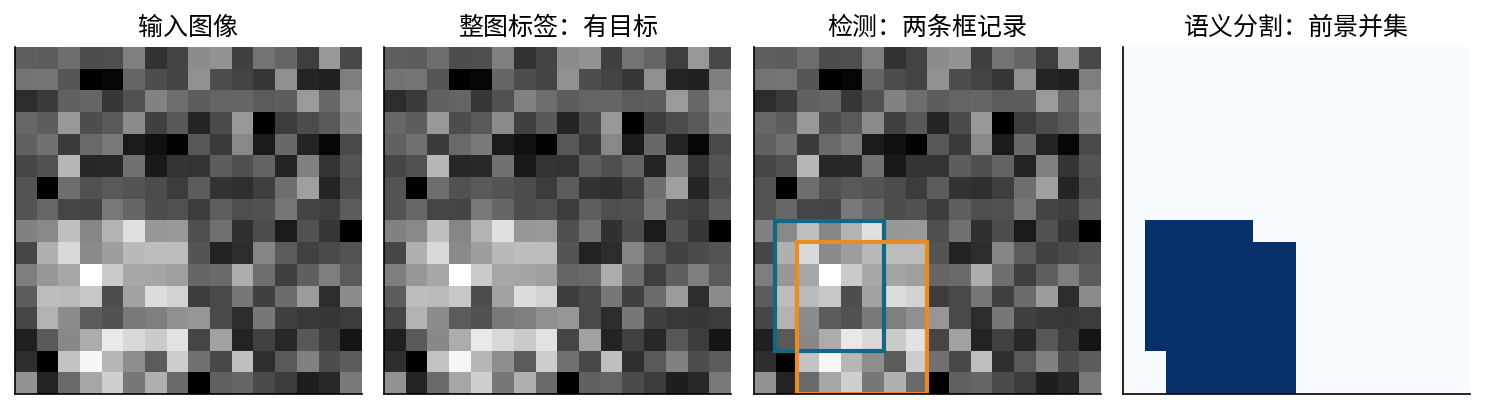

02_iou_branches.png


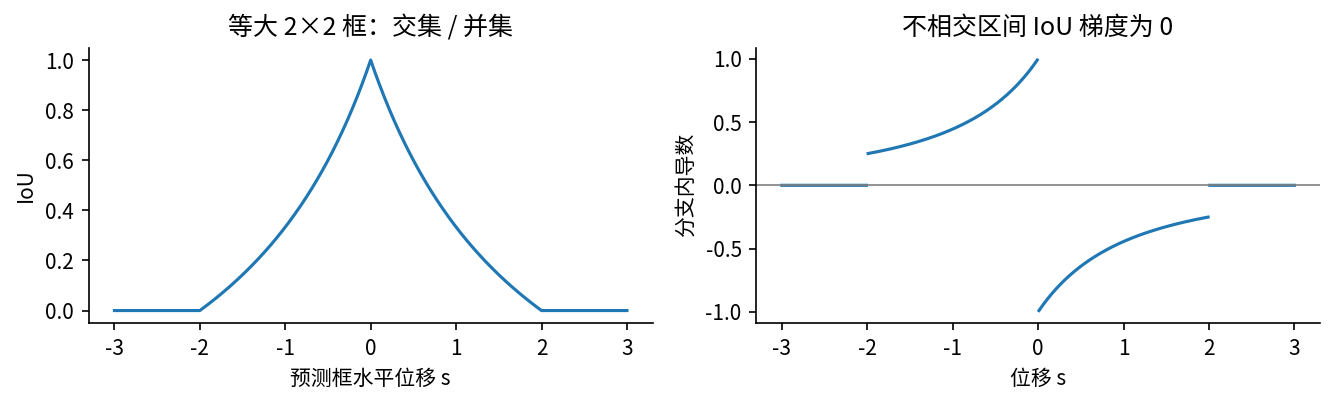

03_box_regression.png


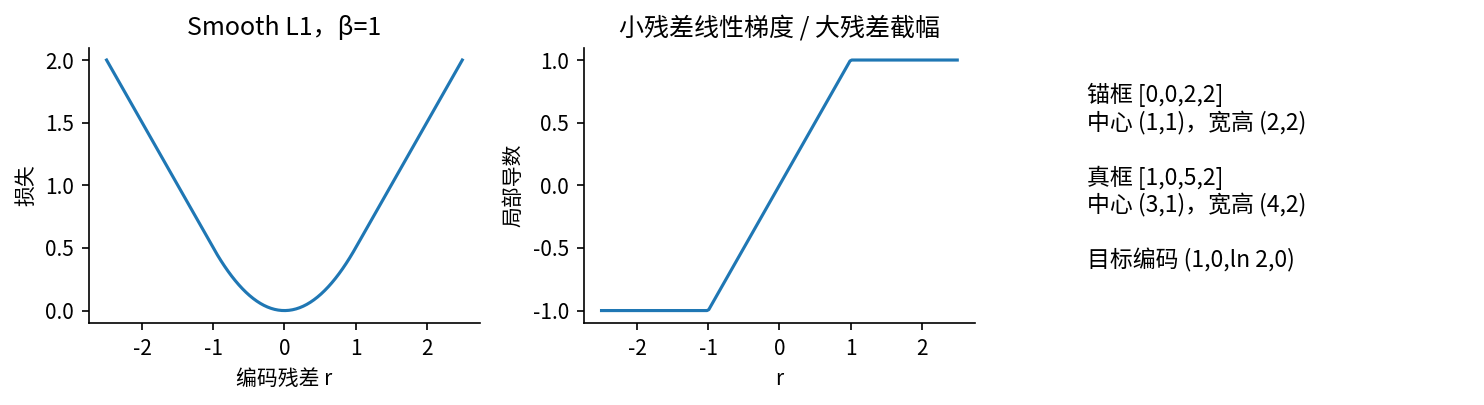

04_matching_nms.png


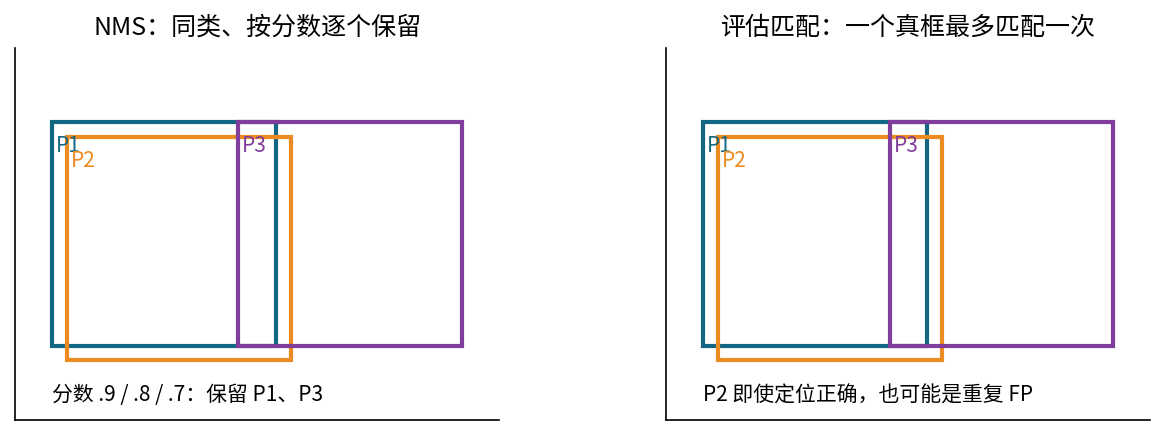

05_ap_convention.png


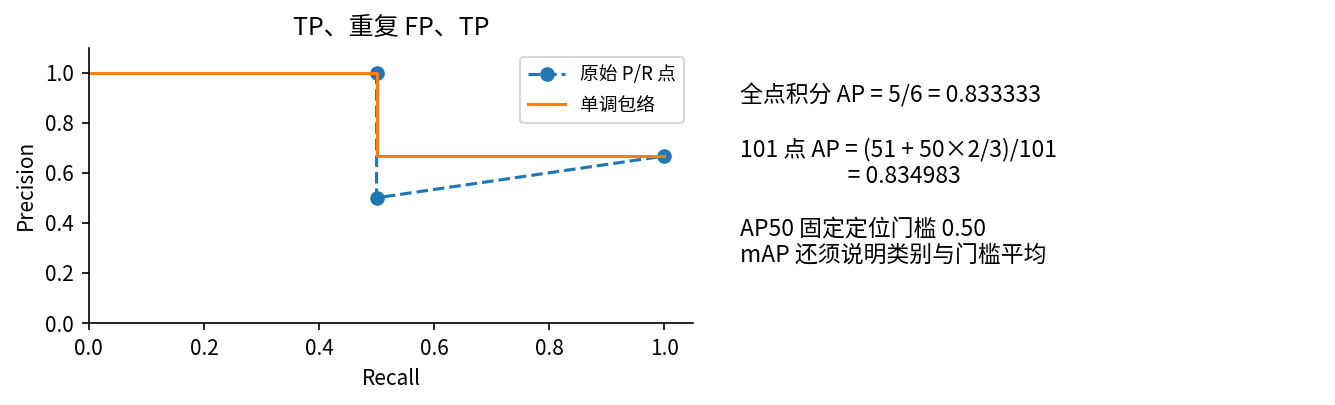

In [9]:
for path in paths[:5]:
    print(path.name)
    display(Image(data=path.read_bytes()))

06_multiscale.png


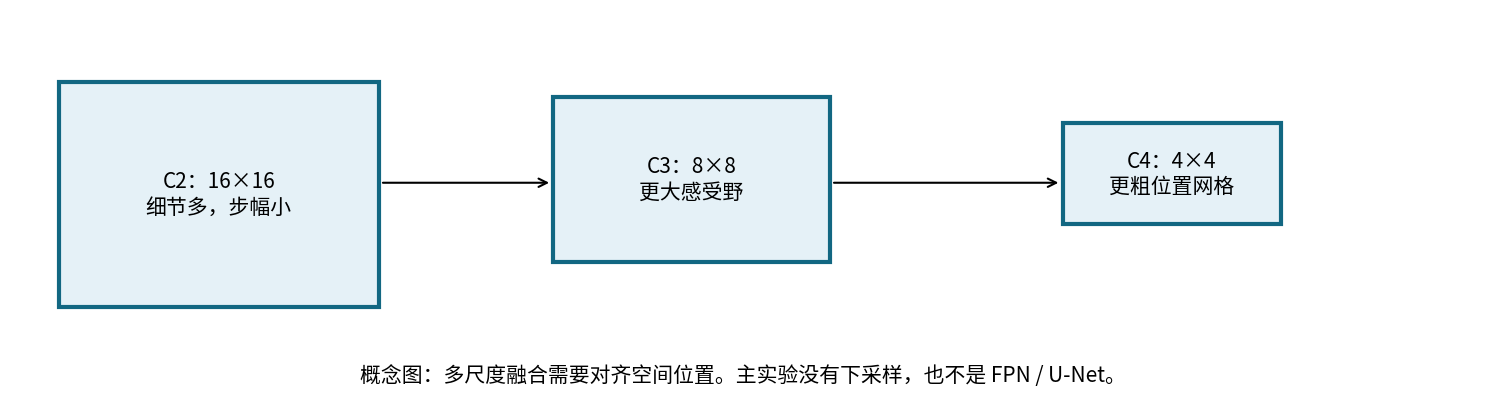

07_hand_gradient.png


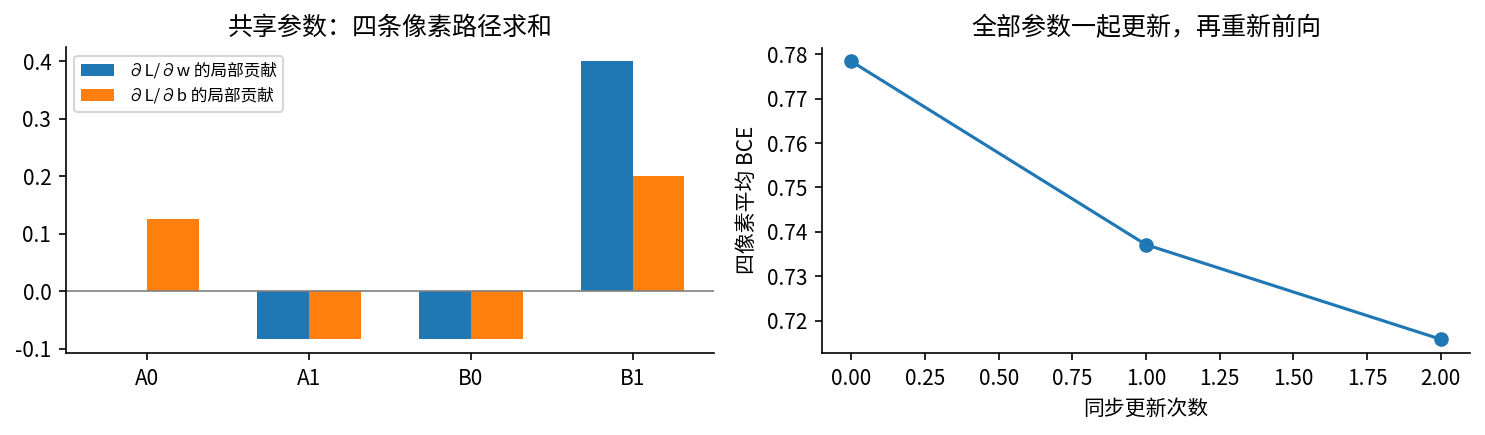

08_data.png


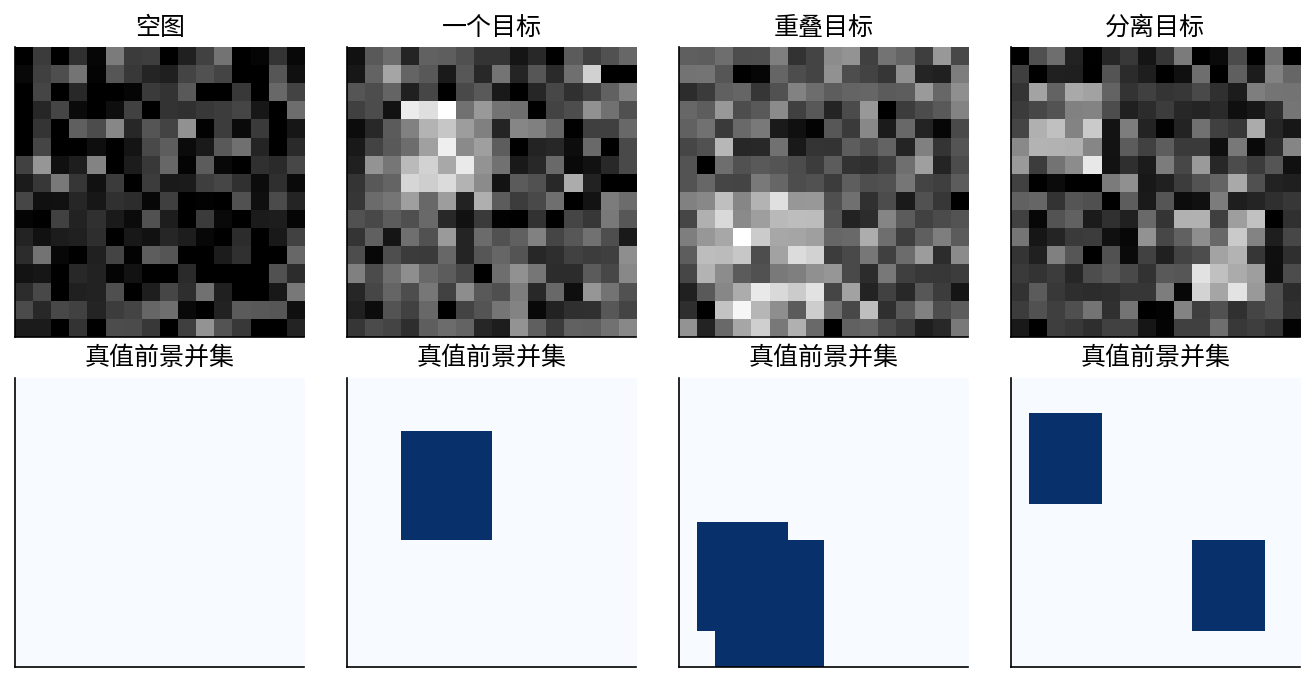

09_all_traces.png


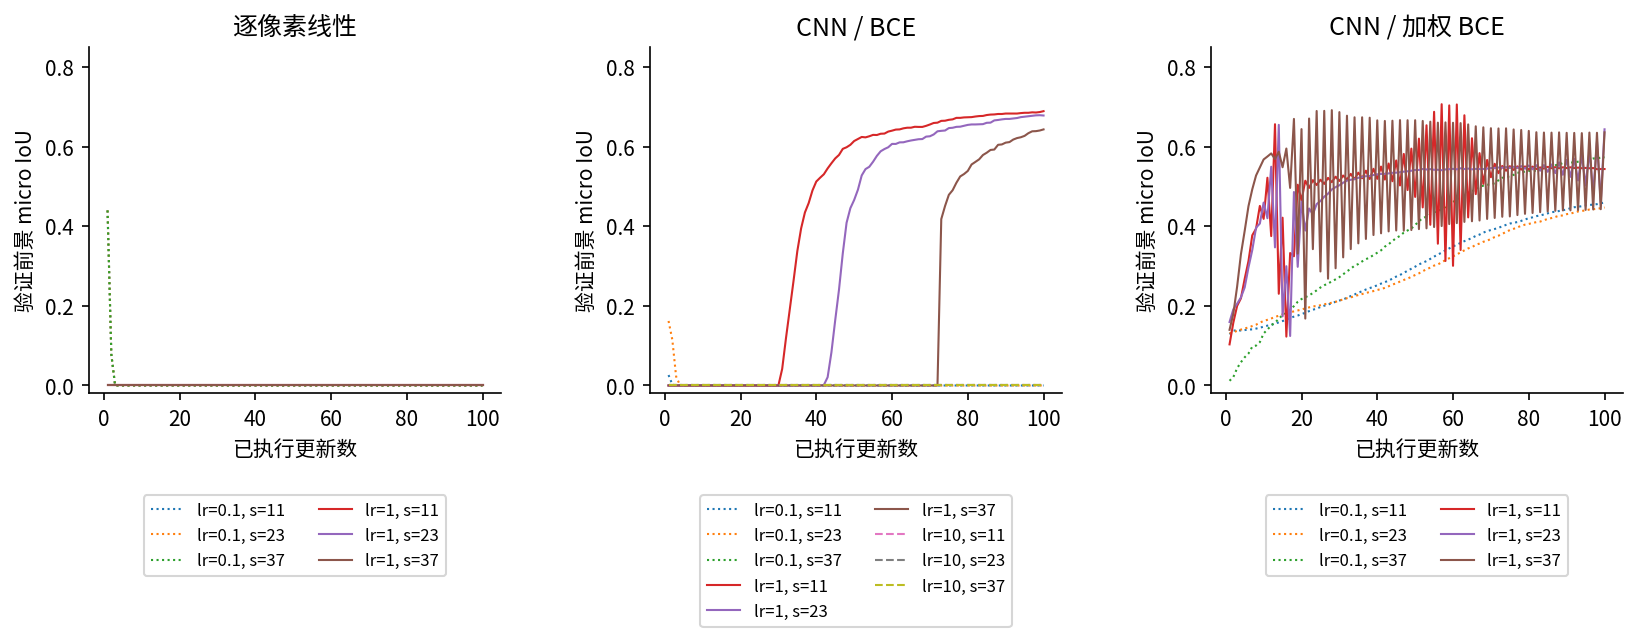

In [10]:
for path in paths[5:9]:
    print(path.name)
    display(Image(data=path.read_bytes()))

10_results.png


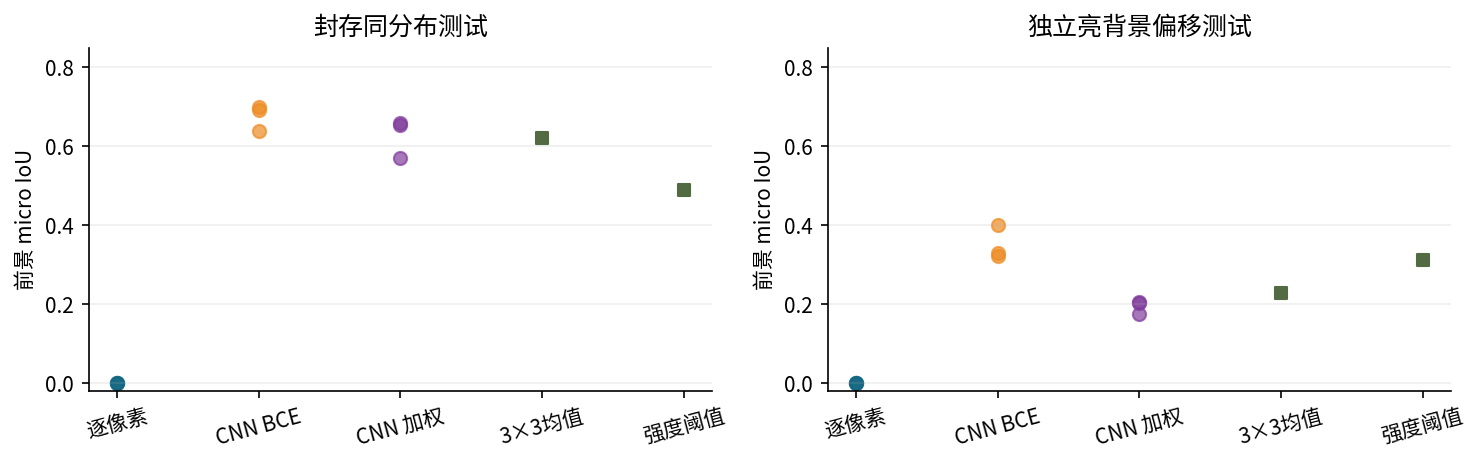

11_predictions.png


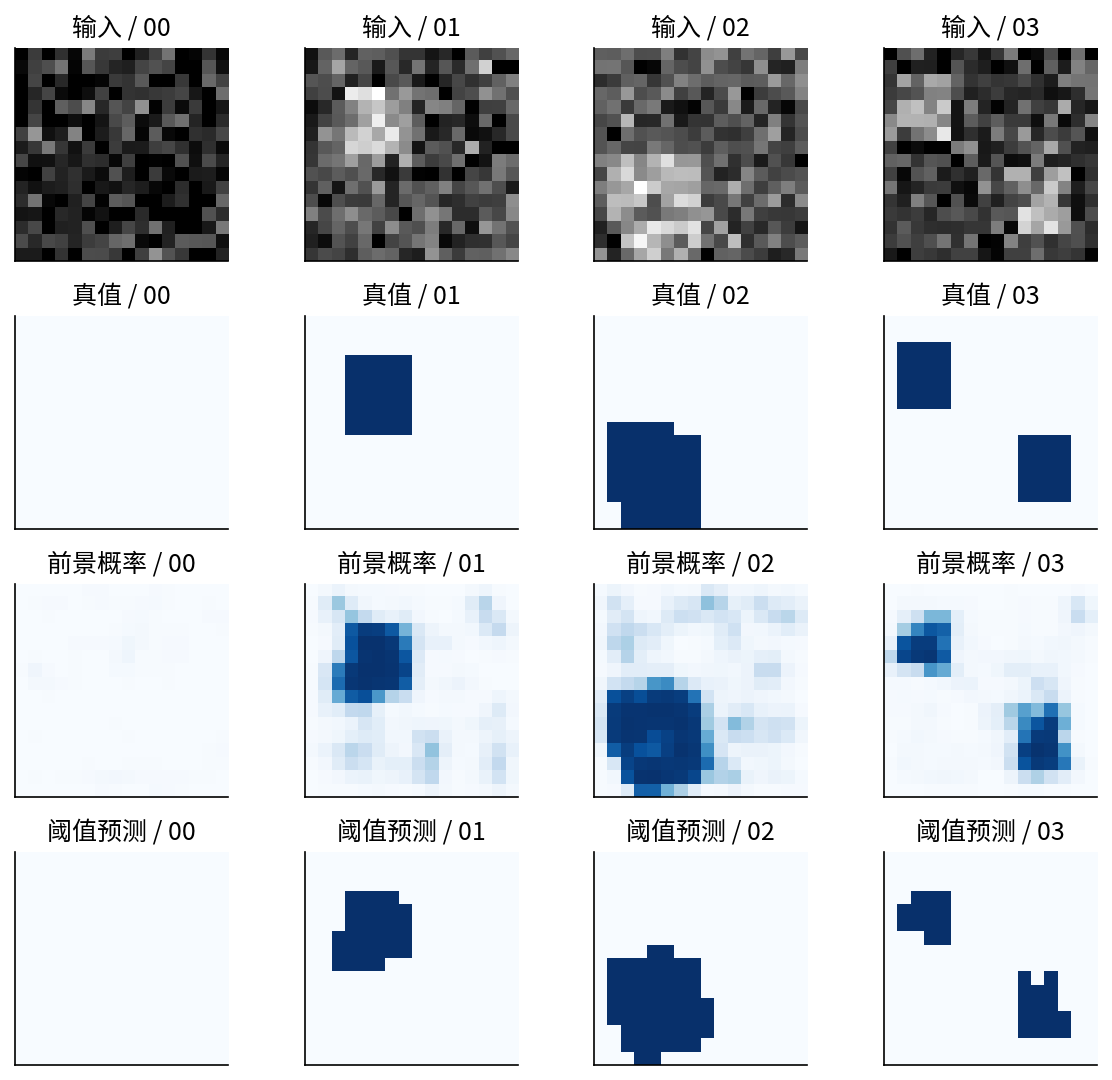

12_all_test_images.png


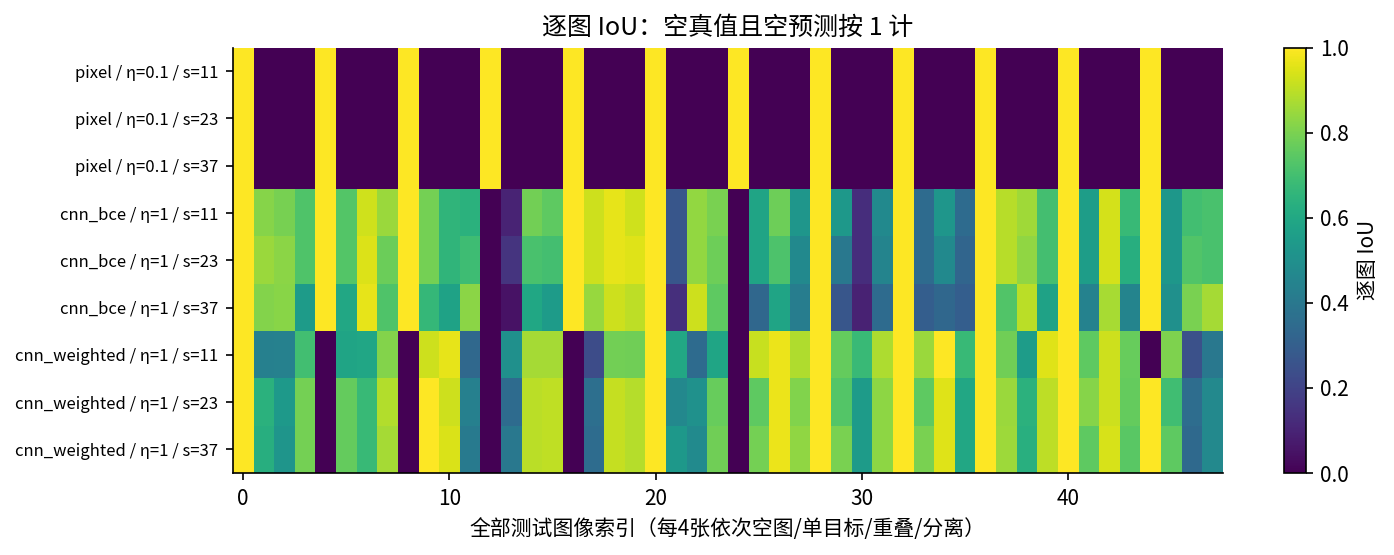

13_threshold_empty.png


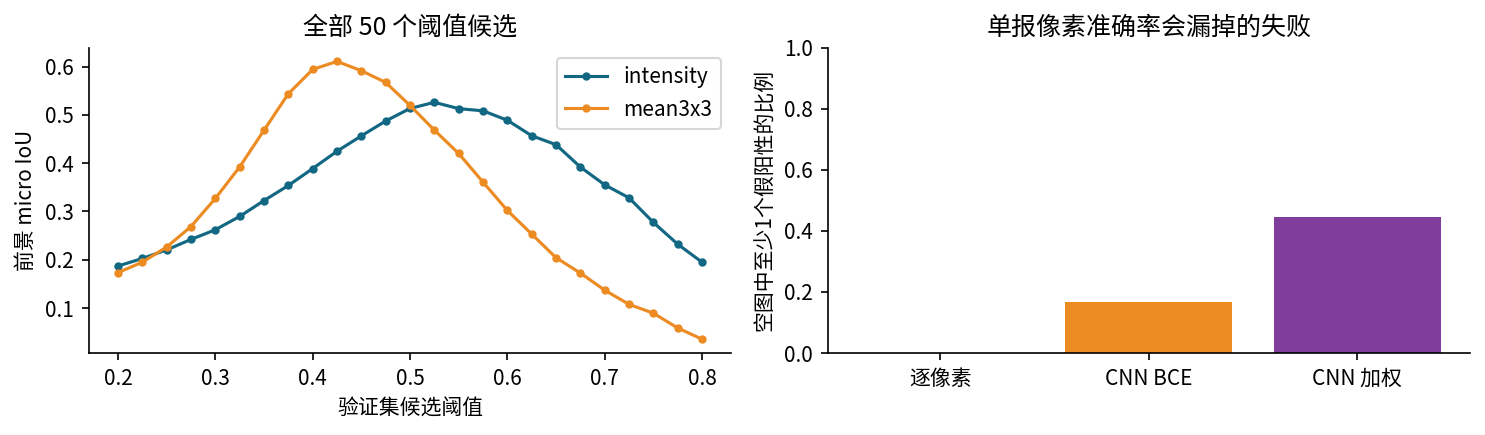

In [11]:
for path in paths[9:]:
    print(path.name)
    display(Image(data=path.read_bytes()))

## 8 结果不是口号
报告原始种子值。相同训练更新预算不意味着相同FLOP。权重改变损失及有效阈值，主实验没有验证集调神经阈值。三种子不等于三份独立测试集。

In [12]:
for arm in ['pixel','cnn_bce','cnn_weighted']:
    rows=[s for s in fresh['selected'] if s['arm']==arm]
    print(arm,'lr',rows[0]['selected_lr'])
    for row in rows:
        print('seed',row['seed'],'test IoU',row['metrics']['test']['foreground_iou_micro'],'shift IoU',row['metrics']['shift']['foreground_iou_micro'],'empty FPR',row['metrics']['test']['empty_false_positive_rate'])
print('全背景测试像素准确率',fresh['baselines']['all_background']['metrics']['test']['pixel_accuracy'])

pixel lr 0.1
seed 11 test IoU 0.0 shift IoU 0.0 empty FPR 0.0
seed 23 test IoU 0.0 shift IoU 0.0 empty FPR 0.0
seed 37 test IoU 0.0 shift IoU 0.0 empty FPR 0.0
cnn_bce lr 1.0
seed 11 test IoU 0.7004470938897168 shift IoU 0.3227491961414791 empty FPR 0.16666666666666666
seed 23 test IoU 0.6911544227886057 shift IoU 0.32868280672958555 empty FPR 0.16666666666666666
seed 37 test IoU 0.6395348837209303 shift IoU 0.4008138351983723 empty FPR 0.16666666666666666
cnn_weighted lr 1.0
seed 11 test IoU 0.5699708454810496 shift IoU 0.17412722210323409 empty FPR 0.5
seed 23 test IoU 0.6584795321637427 shift IoU 0.20593456758813086 empty FPR 0.4166666666666667
seed 37 test IoU 0.6545768566493955 shift IoU 0.2019900497512438 empty FPR 0.4166666666666667
全背景测试像素准确率 0.8984375


## 独立练习

1. 改变空集合约定，只重算指标，哪些排名可能改变？
2. 解释加权CNN空图误报与固定阈值之间的可能关系，并区分观察与机制。
3. 写出公平调阈值的预注册计划；新结论需要新封存测试集。
4. 为什么本Notebook中的AP不能与前景IoU或分类准确率直接对比？

完整任务和答案见lab.md、answers.md。